# Data Cleaning & Visualization using Titanic Dataset

### Internship Task 1 - Thiranex Data Science Internship

**Name:** Obilipapannagari Sathwik Reddy  
**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Better looking graphs
sns.set_style("whitegrid")

## Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(891, 12)

## Data Cleaning

In [7]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [8]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [9]:
df.drop("Cabin", axis=1, inplace=True)

In [10]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Data Visualization

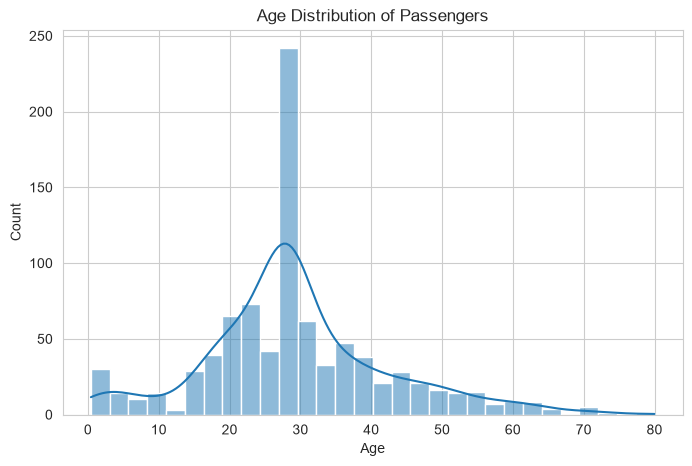

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")

plt.savefig("../images/age_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

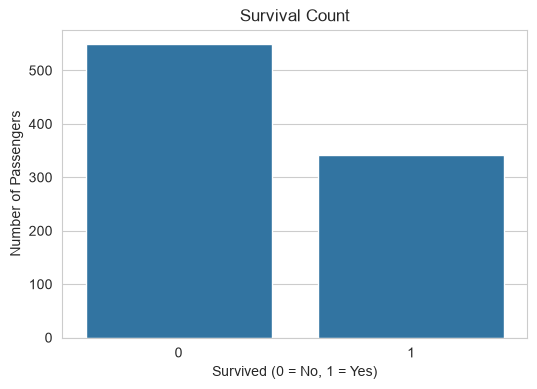

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="Survived", data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.savefig("../images/survival_count.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

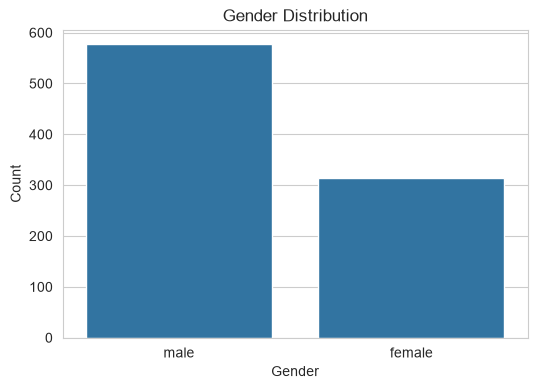

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("../images/gender_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

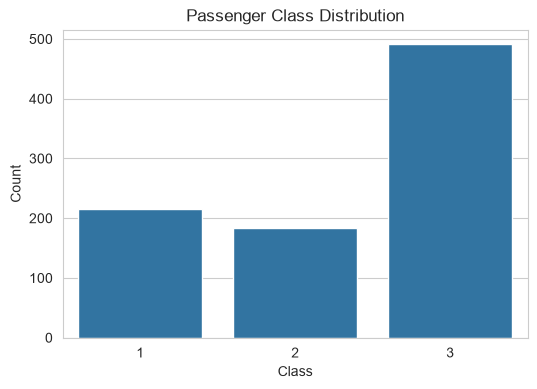

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig("../images/passenger_class_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

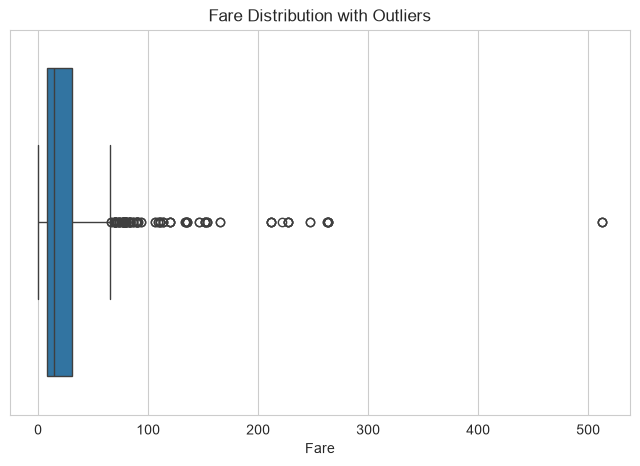

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Fare"])

plt.title("Fare Distribution with Outliers")

plt.savefig("../images/Fare_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [20]:
numeric_df = df.select_dtypes(include=["number"])

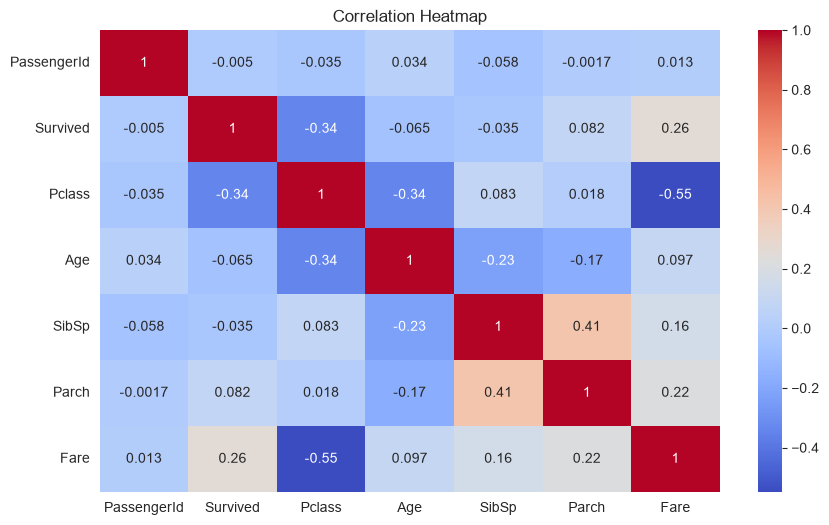

In [21]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

In [23]:
df.to_csv("../data/cleaned_titanic.csv", index=False)

# Insights

- The dataset originally contained missing values in Age, Cabin, and Embarked.
- Missing Age values were filled using the median.
- Missing Embarked values were filled using the mode.
- The Cabin column was removed because it had too many missing values.
- No duplicate records were found.
- Most passengers were between 20 and 40 years old.
- Third-class passengers formed the largest group.
- There were several high fare outliers.
- The cleaned dataset is now ready for further analysis and machine learning.

# Conclusion

In this project, the Titanic dataset was cleaned by handling missing values and removing unnecessary columns. Exploratory visualizations were created to understand passenger demographics, survival distribution, and fare outliers. The cleaned dataset is now suitable for further analysis and machine learning.